In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from sklearn.model_selection import train_test_split
from tqdm import tqdm
import time

--- Загрузка и анализ данных ---
Размер датасета: (35887, 3)

Распределение эмоций:
emotion
3    8989
6    6198
4    6077
2    5121
0    4953
5    4002
1     547
Name: count, dtype: int64


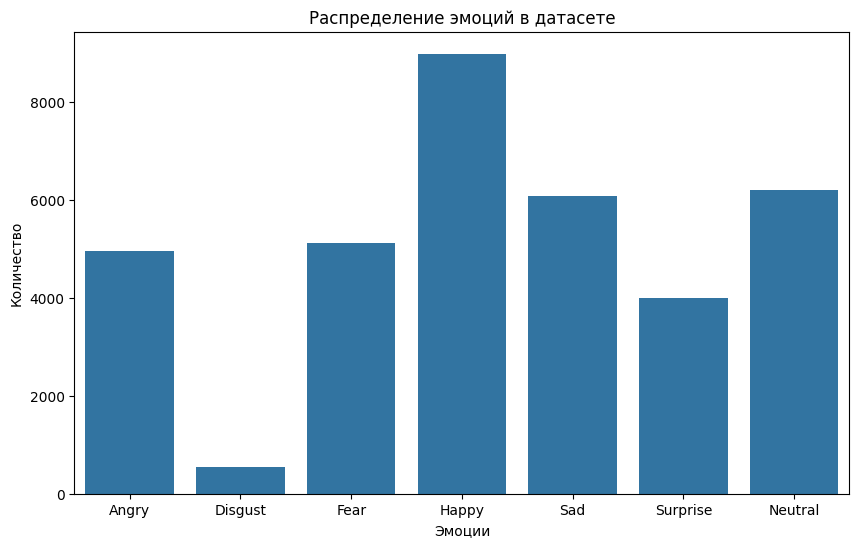

In [2]:
# --- 2. Загрузка и анализ данных ---
print("--- Загрузка и анализ данных ---")
df = pd.read_csv('fer2013.csv')

print(f"Размер датасета: {df.shape}")
print("\nРаспределение эмоций:")
print(df['emotion'].value_counts())

emotion_labels = {0: 'Angry', 1: 'Disgust', 2: 'Fear', 3: 'Happy', 4: 'Sad', 5: 'Surprise', 6: 'Neutral'}

# Визуализация данных (в скрипте это откроет окно, в ноутбуке отобразится в ячейке)
plt.figure(figsize=(10, 6))
sns.countplot(x='emotion', data=df)
plt.title('Распределение эмоций в датасете')
plt.xlabel('Эмоции')
plt.xticks(ticks=list(emotion_labels.keys()), labels=list(emotion_labels.values()))
plt.ylabel('Количество')
plt.show()

In [3]:
# --- 3. Подготовка данных (Transforms, Dataset, DataLoader) ---
print("\n--- Подготовка данных ---")
# Трансформации для аугментации данных и нормализации
train_transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.Resize((48, 48)),
    transforms.Grayscale(num_output_channels=3), # VGG16 ожидает 3 канала
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

test_transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((48, 48)),
    transforms.Grayscale(num_output_channels=3), # VGG16 ожидает 3 канала
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

# Класс Dataset для загрузки данных
class FER2013Dataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.df = dataframe.reset_index(drop=True)
        self.transform = transform
    
    def __len__(self):
        return len(self.df)
    
    def __getitem__(self, idx):
        pixels = self.df.iloc[idx]['pixels']
        emotion = self.df.iloc[idx]['emotion']
        image = np.array([int(p) for p in pixels.split()]).reshape(48, 48).astype('uint8')
        
        if self.transform:
            image = self.transform(image)
        
        return image, emotion

# Разделение данных на обучающую, валидационную и тестовую выборки
train_df, test_df = train_test_split(df, test_size=0.2, random_state=42, stratify=df['emotion'])
train_df, val_df = train_test_split(train_df, test_size=0.2, random_state=42, stratify=train_df['emotion'])

# Создание датасетов и загрузчиков
train_dataset = FER2013Dataset(train_df, transform=train_transform)
val_dataset = FER2013Dataset(val_df, transform=test_transform)
test_dataset = FER2013Dataset(test_df, transform=test_transform)

batch_size = 64
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=0)

print(f"Размеры выборок: Train: {len(train_df)}, Validation: {len(val_df)}, Test: {len(test_df)}")
print(f"Количество батчей: Train: {len(train_loader)}, Validation: {len(val_loader)}")


--- Подготовка данных ---
Размеры выборок: Train: 22967, Validation: 5742, Test: 7178
Количество батчей: Train: 359, Validation: 90


In [4]:
# --- 4. Определение и настройка модели ---
print("\n--- Определение и настройка модели ---")
# Загружаем предобученную VGG16
model = models.vgg16(weights=models.VGG16_Weights.DEFAULT)

# Размораживаем все слои для дообучения
for param in model.parameters():
    param.requires_grad = True

# Правильный расчет количества признаков для классификатора
# VGG16 имеет слой AdaptiveAvgPool(7,7), который на выходе дает тензор 512x7x7.
# После "сплющивания" (flatten) получаем 512 * 7 * 7 = 25088 признаков.
num_features = 512 * 7 * 7

# Заменяем стандартный классификатор VGG16 на наш собственный
model.classifier = nn.Sequential(
    nn.Linear(num_features, 256),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(256, 7) # 7 классов эмоций
)

# Выбор устройства (GPU или CPU)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = model.to(device)

print(f"Используется устройство: {device}")
print(f"Количество обучаемых параметров: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")



--- Определение и настройка модели ---
Используется устройство: cpu
Количество обучаемых параметров: 21,139,271


In [5]:
# --- 5. Определение функций обучения и валидации ---
print("\n--- Определение функций обучения ---")
# Функция потерь, оптимизатор и планировщик
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.0001) # Используем маленький learning rate для fine-tuning
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=3, factor=0.5)

# Функция для одной эпохи обучения
def train_epoch(model, dataloader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    
    for images, labels in tqdm(dataloader, desc='Training'):
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
    
    epoch_loss = running_loss / len(dataloader)
    epoch_acc = 100 * correct / total
    return epoch_loss, epoch_acc

# Функция для одной эпохи валидации
def validate_epoch(model, dataloader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    
    with torch.no_grad():
        for images, labels in tqdm(dataloader, desc='Validation'):
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            running_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    
    epoch_loss = running_loss / len(dataloader)
    epoch_acc = 100 * correct / total
    return epoch_loss, epoch_acc




--- Определение функций обучения ---


In [ ]:
# --- 6. Цикл обучения модели ---
print("\n--- Начало обучения ---")
start_time = time.time()

num_epochs = 10
train_losses, val_losses = [], []
train_accs, val_accs = [], []
best_val_acc = 0.0

for epoch in range(num_epochs):
    print(f"\n--- Эпоха {epoch+1}/{num_epochs} ---")
    
    train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, device)
    train_losses.append(train_loss)
    train_accs.append(train_acc)
    
    val_loss, val_acc = validate_epoch(model, val_loader, criterion, device)
    val_losses.append(val_loss)
    val_accs.append(val_acc)
    
    print(f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}%")
    print(f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.2f}%")
    
    # Сохраняем лучшую модель по точности на валидации
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), 'emotion_model_vgg16.pth')
        print("✓ Модель сохранена! (лучшая точность на валидации)")
        
    scheduler.step(val_loss)

end_time = time.time()
print(f"\nОбучение завершено за {(end_time - start_time)/60:.2f} минут.")
print(f"Лучшая точность на валидации: {best_val_acc:.2f}%")



--- Начало обучения ---

--- Эпоха 1/30 ---


Validation: 100%|██████████| 90/90 [00:23<00:00,  3.81it/s]


Train Loss: 1.3939, Train Acc: 47.12%
Val Loss: 1.1835, Val Acc: 55.61%
✓ Модель сохранена! (лучшая точность на валидации)

--- Эпоха 2/30 ---


Validation: 100%|██████████| 90/90 [00:30<00:00,  2.99it/s]


Train Loss: 1.1606, Train Acc: 56.57%
Val Loss: 1.1135, Val Acc: 59.18%
✓ Модель сохранена! (лучшая точность на валидации)

--- Эпоха 3/30 ---


...

Train Loss: 0.7476, Train Acc: 72.85%
Val Loss: 1.0061, Val Acc: 65.17%
✓ Модель сохранена! (лучшая точность на валидации)

--- Эпоха 9/30 ---


Validation: 100%|██████████| 90/90 [00:30<00:00,  2.91it/s]


Train Loss: 0.6934, Train Acc: 74.77%
Val Loss: 0.9677, Val Acc: 65.90%
✓ Модель сохранена! (лучшая точность на валидации)

--- Эпоха 10/30 ---


Training:  14%|█▎        | 49/359 [00:57<06:03,  1.17s/it]


KeyboardInterrupt: 


--- Визуализация результатов ---


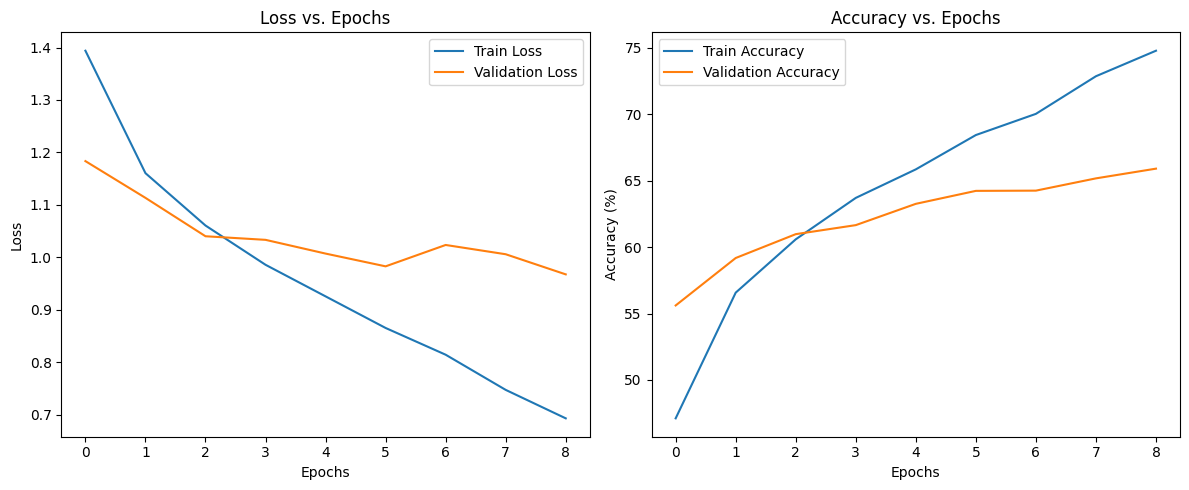


Скрипт завершен.


In [9]:
# --- 7. Визуализация результатов ---
print("\n--- Визуализация результатов ---")
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Validation Loss')
plt.title('Loss vs. Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(train_accs, label='Train Accuracy')
plt.plot(val_accs, label='Validation Accuracy')
plt.title('Accuracy vs. Epochs')
plt.xlabel('Epochs')
plt.ylabel('Accuracy (%)')
plt.legend()

plt.tight_layout()
plt.show()

print("\nСкрипт завершен.")